In [3]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Set Seaborn style for visualizations
sb.set()

In [4]:
# Load the dataset
data = pd.read_csv('combined_cleaned_cardio_data.csv')
print("First few rows of the dataset:")
print(data.head())

First few rows of the dataset:
   id        age  gender  height  weight  ap_hi  ap_lo        cholesterol  \
0   0  50.357290    male     168    62.0    110     80             normal   
1   1  55.381246  female     156    85.0    140     90  well above normal   
2   2  51.627652  female     165    64.0    130     70  well above normal   
3   3  48.249144    male     169    82.0    150    100             normal   
4   4  47.841205  female     156    56.0    100     60             normal   

     gluc  smoke   alco  active  cardio        bmi age_group  \
0  normal  False  False    True   False  21.967120     50-59   
1  normal  False  False    True    True  34.927679     50-59   
2  normal  False  False   False    True  23.507805     50-59   
3  normal  False  False    True    True  28.710479     40-49   
4  normal  False  False   False   False  23.011177     40-49   

            bp_category  
0              elevated  
1  stage 2 hypertension  
2  stage 1 hypertension  
3  stage 2 hypert

In [5]:
# Select features for Multi-Variate Anomaly Detection
features = ["age", "height", "weight", "ap_hi", "ap_lo", "bmi"]
X = data[features].copy()

# Handle missing values
print("Missing values before cleaning:\n", X.isnull().sum())
X.dropna(how='all', subset=features, inplace=True)  # Drop rows with all missing values

# Replace remaining missing values with column means
for column in features:
    if X[column].dtype in ['int64', 'float64']:
        X[column].fillna(X[column].mean(), inplace=True)

print(f"Dataset shape after cleaning: {X.shape}")
if X.shape[0] == 0:
    raise ValueError("No rows remaining after cleaning!")

Missing values before cleaning:
 age       0
height    0
weight    0
ap_hi     0
ap_lo     0
bmi       0
dtype: int64
Dataset shape after cleaning: (70000, 6)


In [6]:
# Apply Local Outlier Factor (LOF) for Multi-Variate Anomaly Detection
num_neighbors = 20      # Number of neighbors
cont_fraction = 0.05    # Fraction of anomalies

lof = LocalOutlierFactor(n_neighbors=num_neighbors, contamination=cont_fraction)
labels = lof.fit_predict(X)  # Predict anomalies

# Append anomaly labels to the dataset for interpretation
X_labeled = X.copy()
X_labeled["Anomaly"] = pd.Categorical(labels)
X_labeled["cardio"] = data["cardio"]  # Add cardio for comparison

print("Summary of anomaly labels:\n", X_labeled["Anomaly"].value_counts())

Summary of anomaly labels:
 1     66500
-1     3500
Name: Anomaly, dtype: int64


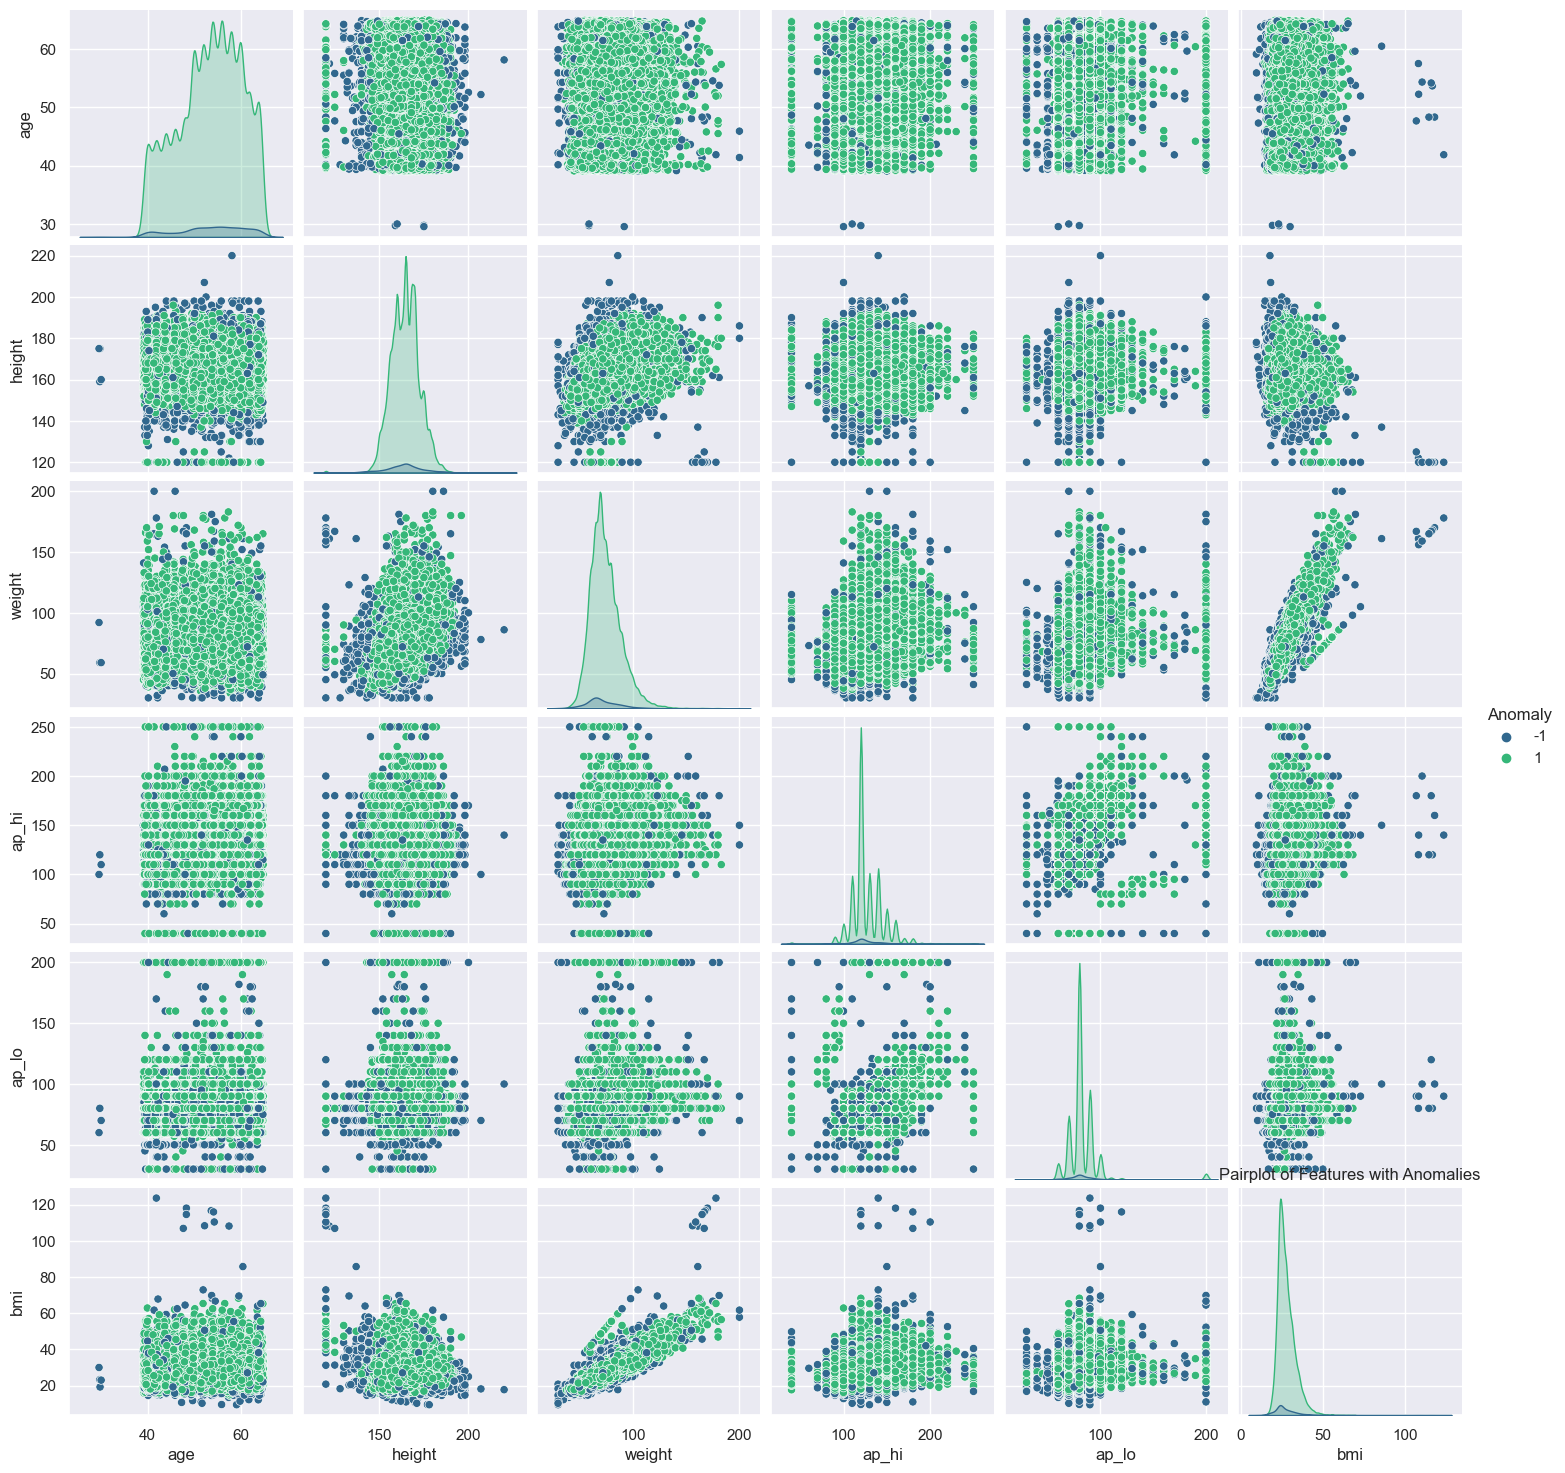

In [7]:
# Visualize Anomalies
# Pairplot of multi-variate features with anomalies highlighted
sb.pairplot(X_labeled, vars=features, hue="Anomaly", palette="viridis")
plt.title("Pairplot of Features with Anomalies")
plt.show()

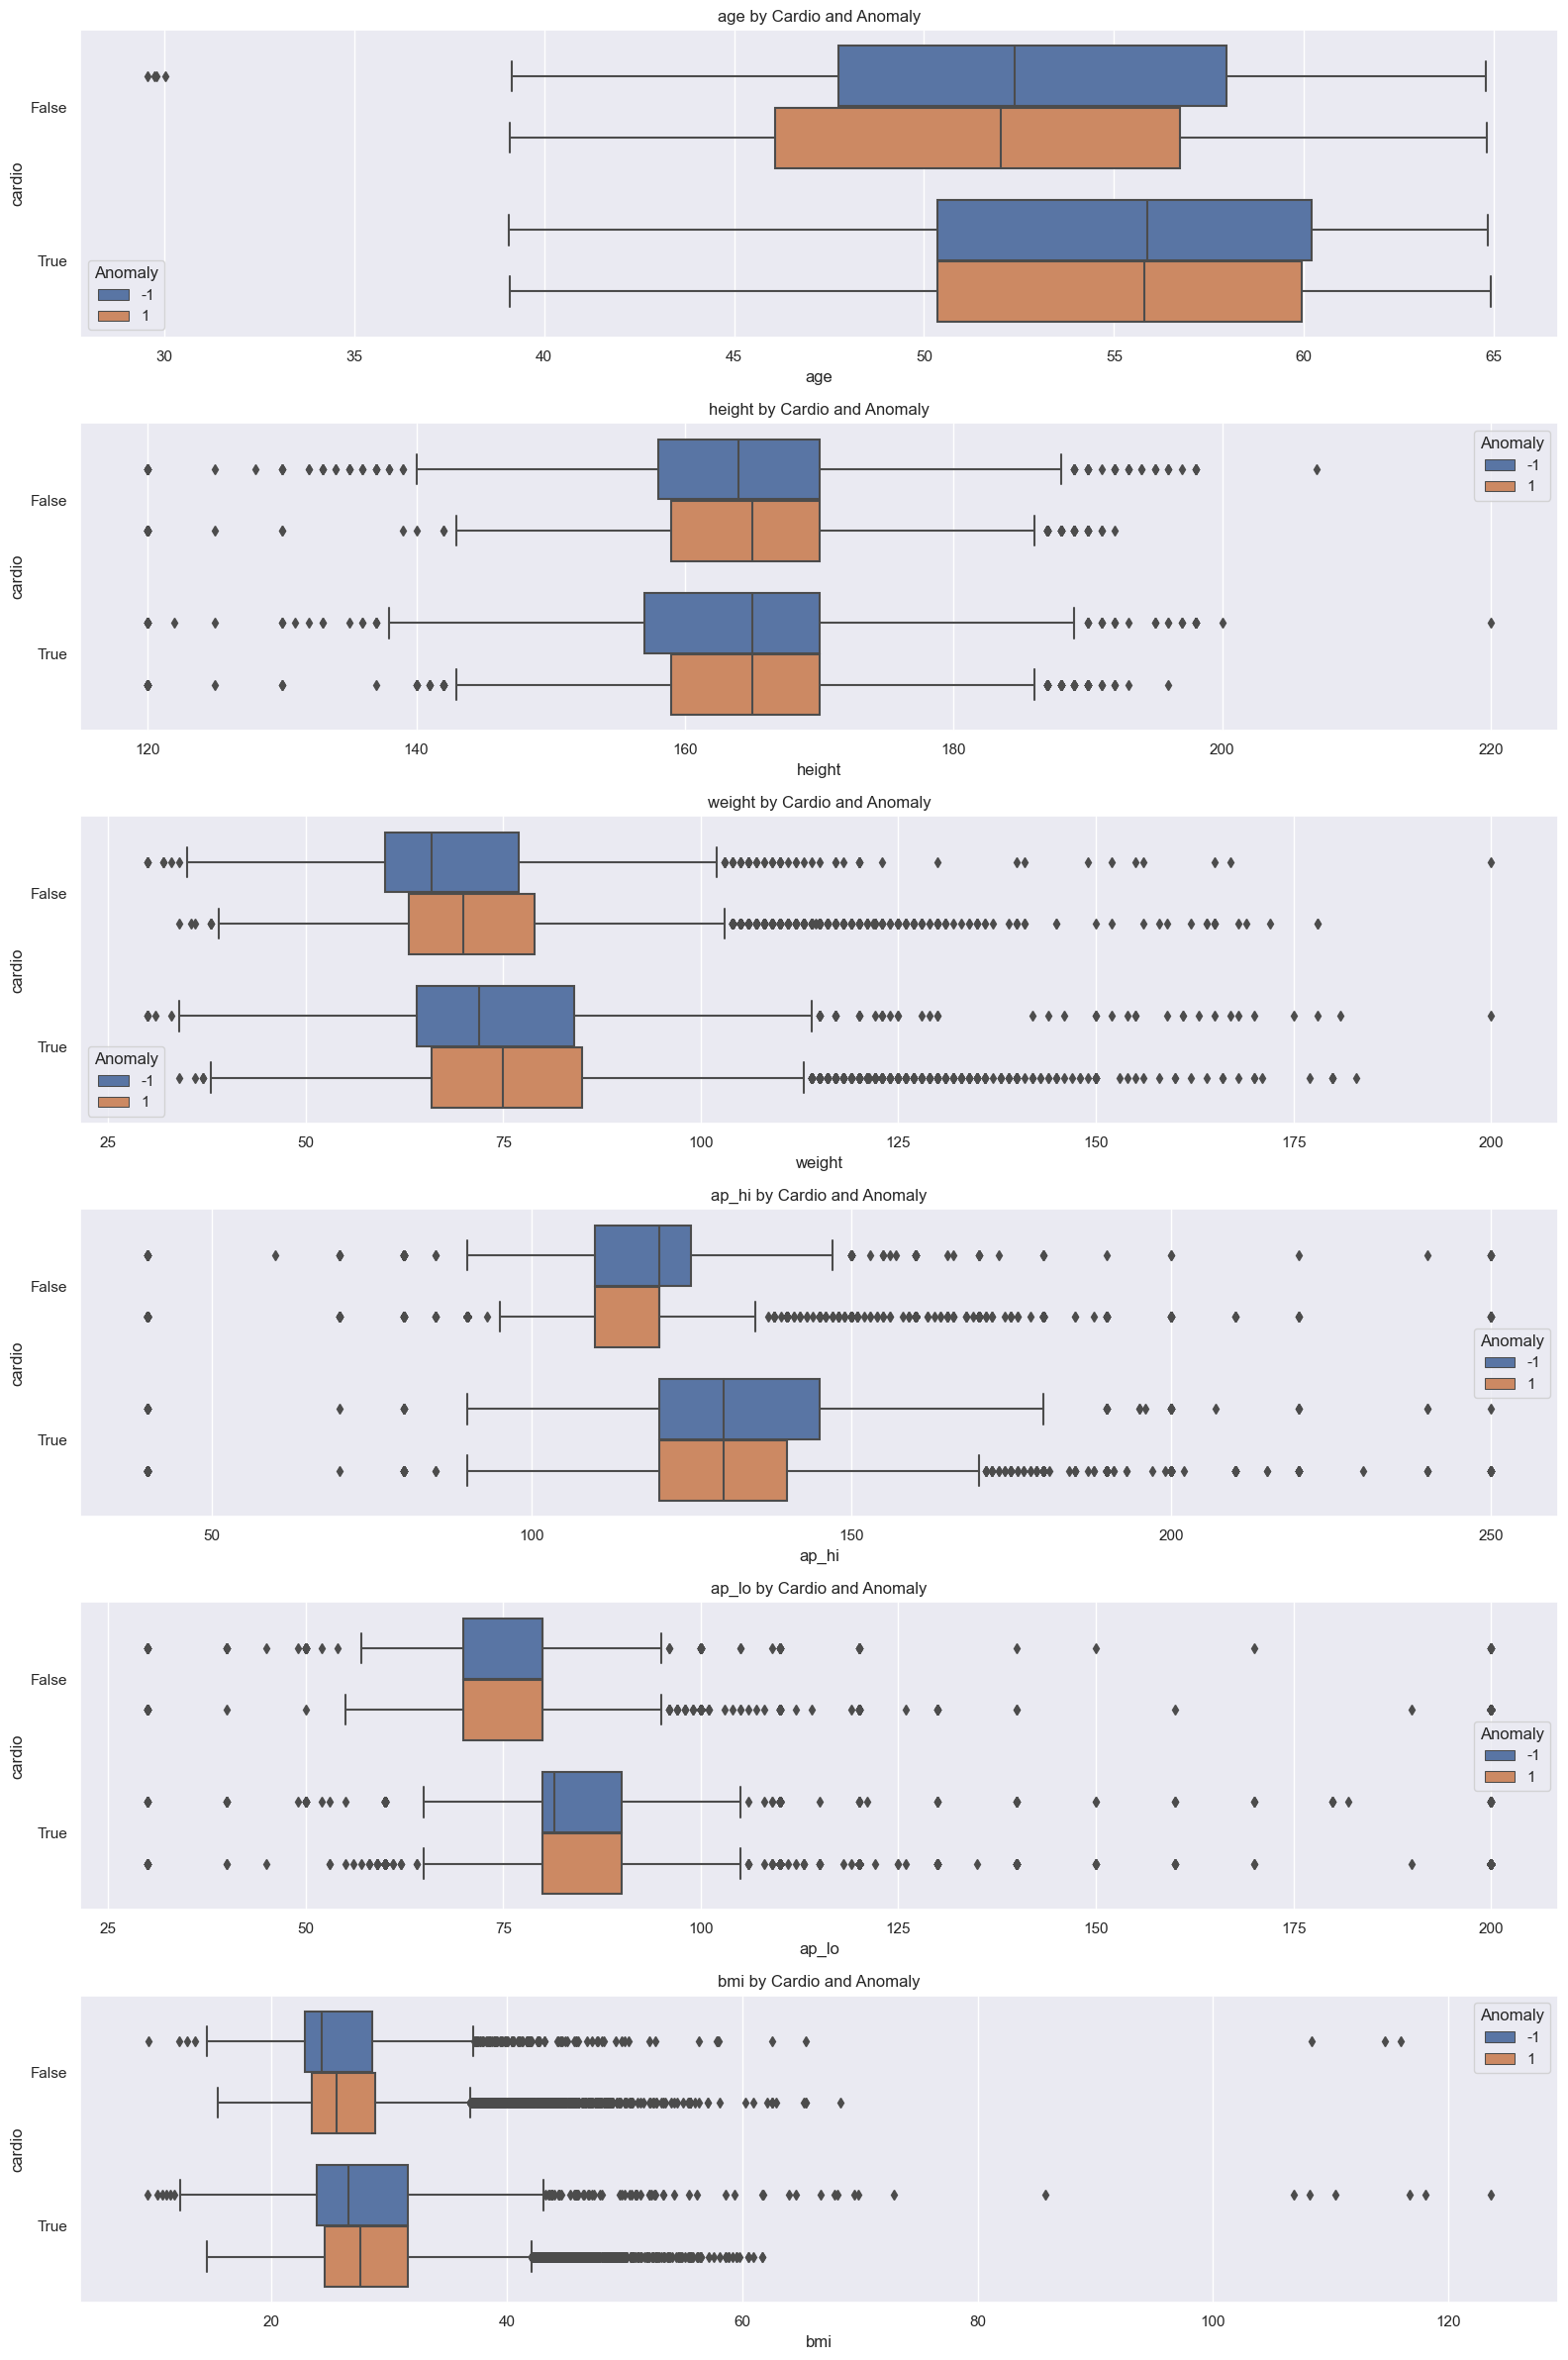

In [8]:
# Compare Features Against Cardio
# Boxplots for all features grouped by cardio and anomalies
f, axes = plt.subplots(len(features), 1, figsize=(16, 24))
for i, feature in enumerate(features):
    sb.boxplot(data=X_labeled, y="cardio", x=feature, hue="Anomaly", ax=axes[i], orient="h")
    axes[i].set_title(f"{feature} by Cardio and Anomaly")
plt.tight_layout()
plt.show()